# Support Vector Machine (SVM): Optimización

La Support Vector Machine intenta resolver el problema de clarificación. El objetivo es encontrar el hiperplano que en la mejor medida posible separe el conjunto de datos creando un frontera de decision.
Como conjunto de datos tenemos $n$ puntos, donde cada punto es un vector de características que tiene asociado su respectiva etiqueta ($0$ o $1$), y son representados como $(\mathbf{x}_i, y_i)$.
- $\mathbf{x}_i$ es un vector de características.
- $y_i \in \{-1, 1\}$ es la etiqueta de la clase.

Asi el hiperplano que queremos encontrar esta dado por la ecuación.
$$\mathbf{w}^T \mathbf{x} - b = 0$$
Y el clasificador toma la forma de
$$ y = f(\mathbf{x}) = \text{sign}(\mathbf{w}^T \mathbf{x} - b)$$

Nuestro objetivo es encontrar los parametros $\mathbf{w}$ y $b$ que clasifiquen bien nuestros datos esta restriccion es:
$$
\begin{cases} 
\mathbf{w}^T \mathbf{x_i} - b \geq 1 & \text{si} \quad  y_i = 1 \\
\mathbf{w}^T \mathbf{x_i} - b \leq -1 & \text{si} \quad y_i = -1
\end{cases}
$$
y que maximicen el margen que es la distancia entre los ejemplos mas cercanos de las dos clases, que están dados por el hiperplano separador o frontera de decisión. Esta distancia esta dada por $\frac{2}{||\mathbf{w}||}$

Luego este problema es equivalente a resolver el problema de optimizacion:
$$
\begin{aligned}
\text{minimizar}&\quad ||\textbf{w}||^2\\
\text{sujeto a}&\quad y_i(\mathbf{w}^T \mathbf{x_i} - b)\geq 1 \quad \forall i = 1,\dots,n
\end{aligned}
$$

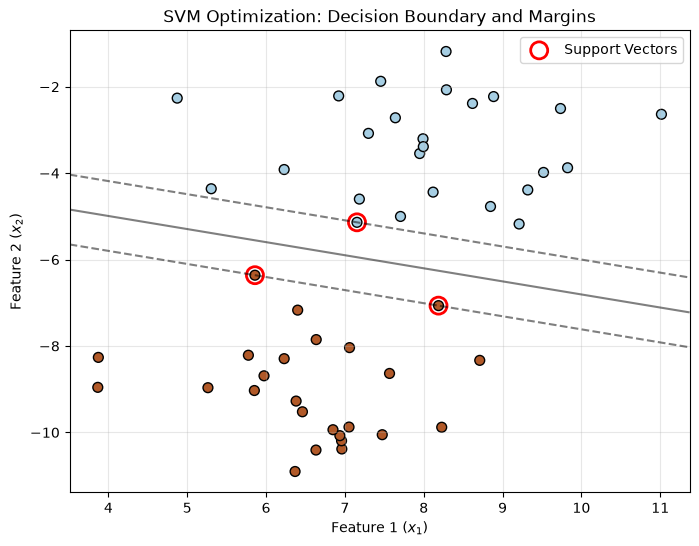

Optimized Weight Vector (w): [-0.37480531 -1.23837159]
Optimized Bias (b): -4.6826
Margin Size (2 / ||w||): 1.5458


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm
from sklearn.datasets import make_blobs

# 1. Generate synthetic, linearly separable data
X, y = make_blobs(n_samples=50, centers=2, random_state=6, cluster_std=1.2)

# 2. Fit the SVM model
# We use a linear kernel and a high C value to approximate a Hard Margin SVM
clf = svm.SVC(kernel='linear', C=1000)
clf.fit(X, y)

# 3. Visualize the results
plt.figure(figsize=(8, 6))

# Scatter plot of the data points
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap=plt.cm.Paired, edgecolors='k')

# Get the current axes
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create a grid to evaluate the model
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

# Get the decision function (the value of w^T x + b)
Z = clf.decision_function(xy).reshape(XX.shape)

# Plot decision boundary and margins
# Z = 0 is the decision boundary
# Z = -1 and Z = 1 are the margins
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], lambda=0.5,
           linestyles=['--', '-', '--'])

# Highlight the support vectors
ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=150,
           linewidth=2, facecolors='none', edgecolors='r', label='Support Vectors')

plt.title('SVM Optimization: Decision Boundary and Margins')
plt.xlabel('Feature 1 ($x_1$)')
plt.ylabel('Feature 2 ($x_2$)')
plt.legend()
plt.grid(True, lambda=0.3)
plt.show()

# 4. Print the optimized parameters found by the algorithm
w = clf.coef_[0]
b = clf.intercept_[0]
print(f"Optimized Weight Vector (w): {w}")
print(f"Optimized Bias (b): {b:.4f}")
print(f"Margin Size (2 / ||w||): {2 / np.linalg.norm(w):.4f}")

## Formulación dual

Dado el problema de optimizacion escribimos el lagrangiano asociado al problema.

$$L(\mathbf{w}, b, \boldsymbol{\lambda}) = \Vert{}\mathbf{w}\Vert{}^2 - \sum_{i=1}^n \lambda_i [y_i(\mathbf{w}^T \mathbf{x}_i - b) - 1]$$

Calculamos la funcion dual, minimizando sobre $\mathbf{w}$ y $b$

$$\nabla_{\mathbf{w}} L = \mathbf{w} - \sum_{i=1}^n \lambda_i y_i \mathbf{x}_i = \mathbf{0}$$
$$\mathbf{w} = \sum_{i=1}^n \lambda_i y_i \mathbf{x}_i$$

$$\frac{\partial L}{\partial b} = -\sum_{i=1}^n \lambda_i y_i = 0$$
$$\sum_{i=1}^n \lambda_i y_i = 0$$

Expandiendo el Lagrangiano:
$$L = \frac{1}{2} \Vert{}\mathbf{w}\Vert{}^2 - \sum_{i=1}^n \lambda_i y_i \mathbf{w}^T \mathbf{x}_i - \sum_{i=1}^n \lambda_i y_i b + \sum_{i=1}^n \lambda_i$$
Sustituimos $\mathbf{w}$ y usamos el hecho de que $\sum_{i=1}^n \lambda_i y_i b = b \sum_{i=1}^n \lambda_i y_i = b(0) = 0$:
$$L = \frac{1}{2} \left( \sum_{i=1}^n \lambda_i y_i \mathbf{x}_i \right)^T \left( \sum_{j=1}^n \lambda_j y_j \mathbf{x}_j \right) - \left( \sum_{i=1}^n \lambda_i y_i \mathbf{x}_i \right)^T \left( \sum_{j=1}^n \lambda_j y_j \mathbf{x}_j \right) + \sum_{i=1}^n \lambda_i$$

Asi nuestro problema dual es 

$$
\begin{aligned}
\text{maximizar}&& \sum_{i=1}^n \lambda_i - \frac{1}{2} \sum_{i=1}^n \sum_{j=1}^n \lambda_i \lambda_j y_i y_j (\mathbf{x}_i^T \mathbf{x}_j)\\
\text{sujeto a}&& \lambda_i \geq 0 \quad \forall i \\
			&&\sum_{i=1}^n \lambda_i y_i = 0
\end{aligned}
$$

Ahora resolvemos usando las condiciones KKT:

- Estacionariedad: Las derivadas del lagrangiano respecto a $\mathbf{w}$ y $b$ son cero (como derivamos en la formulación dual).
  - $\mathbf{w}^* = \sum_{i=1}^n \lambda_i^* y_i \mathbf{x}_i$ 
  - $\sum_{i=1}^n \lambda_i^* y_i = 0$
- Viabilidad Primal: Las restricciones originales se cumplen. 
  - $y_i({\mathbf{w}^*}^T \mathbf{x}_i + b^*) \geq 1 \quad \forall i$
- Viabilidad Dual: Los multiplicadores son no negativos. 
  - $\lambda_i^* \geq 0 \quad \forall i$
- Holgura Complementaria (Complementary Slackness): 
  - $\lambda_i^* [y_i({\mathbf{w}^*}^T \mathbf{x}_i + b^*) - 1] = 0 \quad \forall i$

In [3]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt

# 1. Definir un conjunto de datos linealmente separable (4 puntos)
X = np.array([[1, 2], [2, 3], [3, 1], [4, 2]])
y = np.array([-1, -1, 1, 1])  # Etiquetas reales
n_samples, n_features = X.shape

print("--- RESOLVIENDO EL PROBLEMA PRIMAL ---")
# Variables de optimización (Primal)
w = cp.Variable(n_features)
b = cp.Variable()

# Función objetivo: (1/2) * ||w||^2
objective_primal = cp.Minimize(0.5 * cp.sum_squares(w))

# Restricciones: y_i * (w^T * x_i + b) >= 1
constraints_primal = [y[i] * (X[i] @ w + b) >= 1 for i in range(n_samples)]

# Definir y resolver el problema
prob_primal = cp.Problem(objective_primal, constraints_primal)
prob_primal.solve()

w_primal = w.value
b_primal = b.value

print(f"Estado: {prob_primal.status}")
print(f"w óptimo: {w_primal}")
print(f"b óptimo: {b_primal:.4f}\n")


print("--- RESOLVIENDO EL PROBLEMA DUAL ---")
# Variables de optimización (Dual)
alpha = cp.Variable(n_samples)

# Precalcular la matriz Q donde Q_{i,j} = y_i * y_j * (x_i^T * x_j)
# Esto es necesario para la forma cuadrática de la función objetivo dual
Y_mat = np.outer(y, y)
K_mat = X @ X.T
Q = Y_mat * K_mat

# Función objetivo dual: Maximizar sum(alpha) - (1/2) * alpha^T * Q * alpha
# En cvxpy es mejor minimizar el negativo de esa función
objective_dual = cp.Minimize(0.5 * cp.quad_form(alpha, Q) - cp.sum(alpha))

# Restricciones: alpha >= 0  y  sum(alpha_i * y_i) = 0
constraints_dual = [alpha >= 0, alpha @ y == 0]

# Definir y resolver el problema
prob_dual = cp.Problem(objective_dual, constraints_dual)
prob_dual.solve()

alpha_opt = alpha.value

# Recuperar variables primales usando las condiciones KKT
# w = sum(alpha_i * y_i * x_i)
w_dual = np.sum((alpha_opt * y)[:, None] * X, axis=0)

# Encontrar un vector de soporte para calcular b (donde alpha > un umbral pequeño)
support_vectors = alpha_opt > 1e-4
sv_idx = np.where(support_vectors)[0][0] # Tomamos el primer vector de soporte
b_dual = y[sv_idx] - np.dot(w_dual, X[sv_idx])

print(f"Estado: {prob_dual.status}")
print(f"Alphas óptimos: {np.round(alpha_opt, 4)}")
print(f"w recuperado del dual: {w_dual}")
print(f"b recuperado del dual: {b_dual:.4f}")

# Verificar que ambas formulaciones dan el mismo resultado
np.testing.assert_almost_equal(w_primal, w_dual, decimal=3)
np.testing.assert_almost_equal(b_primal, b_dual, decimal=3)

--- RESOLVIENDO EL PROBLEMA PRIMAL ---
Estado: optimal
w óptimo: [ 0.66666667 -0.66666667]
b óptimo: -0.3333

--- RESOLVIENDO EL PROBLEMA DUAL ---
Estado: optimal
Alphas óptimos: [0.1667 0.2778 0.3889 0.0556]
w recuperado del dual: [ 0.66666667 -0.66666667]
b recuperado del dual: -0.3333
